**Phase 2: Setup Importing libraries and loading the required datasets**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
orders_df=pd.read_csv("/content/orders DA.csv")
customers_df=pd.read_csv("/content/customers DA.csv")
inventory_df=pd.read_csv("/content/inventory DA.csv")
order_items_df=pd.read_csv("/content/order_items DA.csv")
payments_df=pd.read_csv("/content/payments DA.csv")
products_df=pd.read_csv("/content/products DA.csv")
returns_df=pd.read_csv("/content/returns DA.csv")
suppliers_df=pd.read_csv("/content/suppliers DA.csv")
print("All * datasets are loaded successfully")

All * datasets are loaded successfully


**1.	Monthly order volume -- Bar graph**

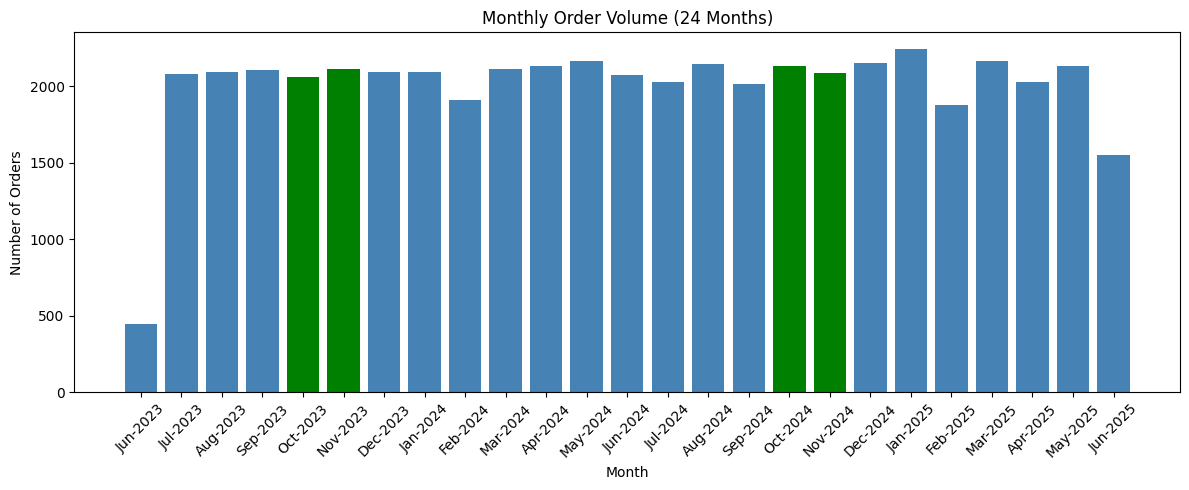

In [13]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'],format='%d-%m-%Y')


monthly_orders = (
    orders_df
    .groupby(orders_df['order_date'].dt.to_period('M'))
    .size()
)

monthly_orders.index = monthly_orders.index.to_timestamp()

colors = [
    'green' if month.month in [10, 11] else 'steelblue'
    for month in monthly_orders.index
]

plt.figure(figsize=(12,5))
plt.bar(monthly_orders.index.strftime('%b-%Y'),
        monthly_orders.values,
        color=colors)

plt.title("Monthly Order Volume (24 Months)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1__Monthly_order_volume.png')
plt.show()

**Observation:Order volume remains stable throughout the year averaging around 2000 orders per month. There is a slight but noticeable hike during diwali festivalsessions(OCT AND NOV) in both 2023 and 2024. june 2023 and june 2025 show lower volumes likely indicating that there are partial month in the dataset**

**2.	Monthly revenue (GMV) — line graph**

In [14]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['month_year'] = orders_df['order_date'].dt.strftime('%Y-%m')

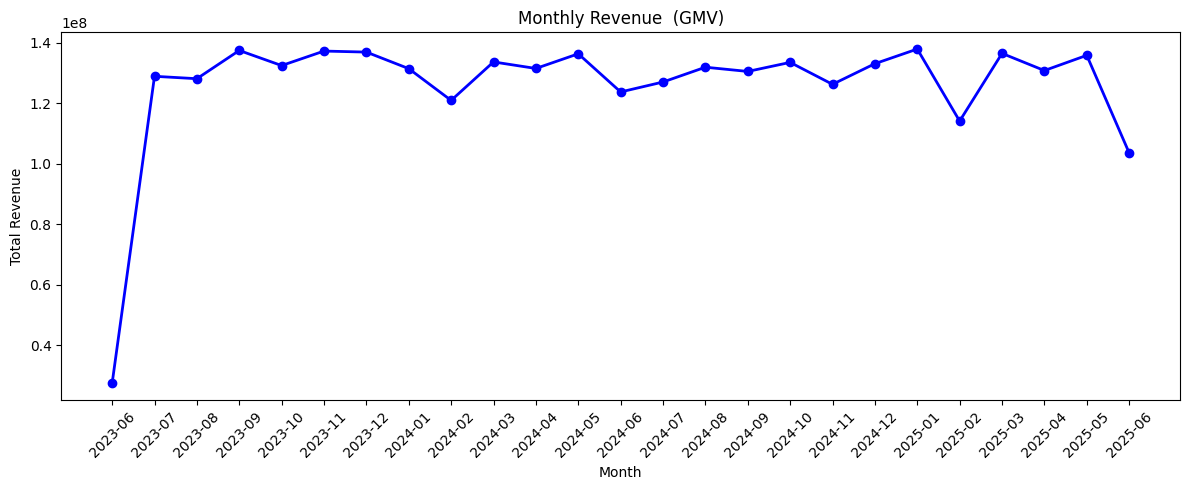

In [15]:
monthly_revenue = (
    orders_df.groupby('month_year')['final_amount']
    .sum()
    .sort_index()
)
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index,monthly_revenue.values,marker='o',color='blue',linewidth=2)

plt.title('Monthly Revenue  (GMV)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chart2__Monthly_revenue.png')
plt.show()

**Monthly revenue (GMV) — shows the line graph feb month small drop of revenue and also june month**

**3. Category-wise revenue share — a pie chart**

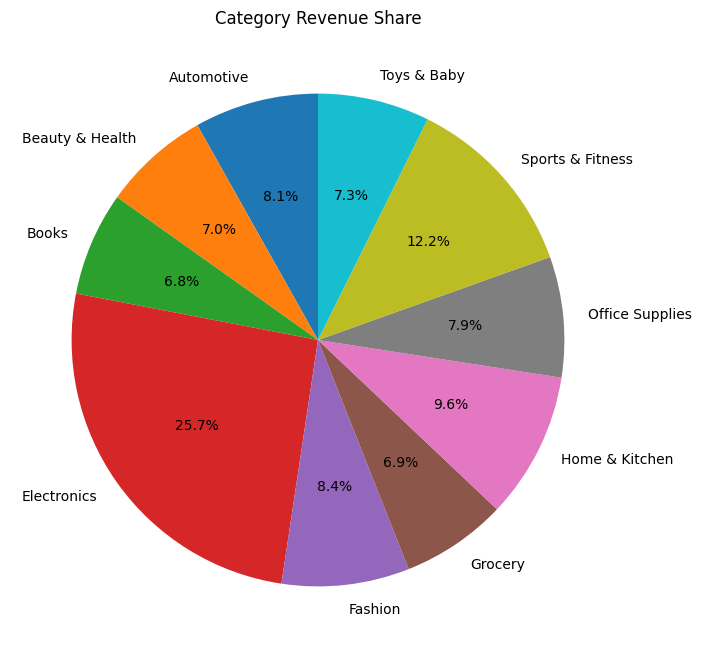

In [16]:
# Merge order_items with orders
category_sales = order_items_df.merge(
    orders_df[['order_id', 'final_amount']],
    on='order_id',
    how='inner'
)

# Revenue by category
category_revenue = category_sales.groupby('category')['final_amount'].sum()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Category Revenue Share")
plt.savefig("chart3_category_revenue.png")
plt.show()

**Category-wise revenue share —In this pie chart Electronics category earns the most out of the all categories with the 25.7% of revenue share**

**4.	Order status distribution — a donut chart**

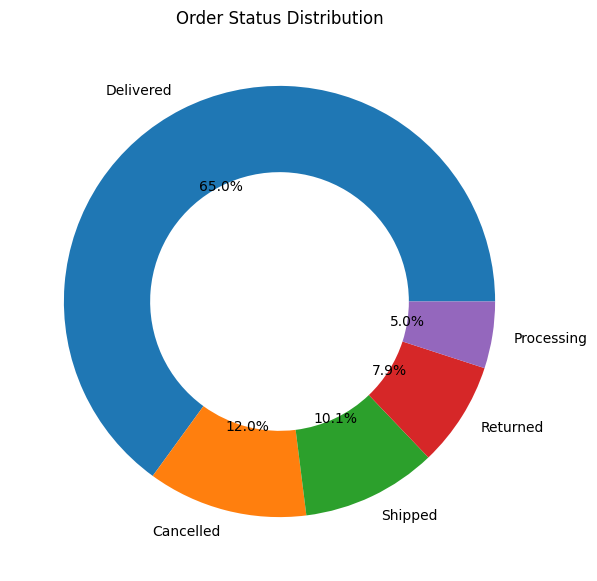

In [17]:
status = orders_df['status'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status,
        labels=status.index,
        autopct='%1.1f%%',
        wedgeprops={'width':0.4})

plt.title("Order Status Distribution")
plt.savefig('chart4_status_distribution.png')
plt.show()

**Order status distribution In this donut chart showing % of Delivered, Cancelled, Returned, Shipped, Processing of Order status distribution ,among all distributions 65% of orders are delivered**

**5.	Top 10 states by number of orders — a horizontal bar chart**

state
Uttar Pradesh     9507
Maharashtra       8179
Gujarat           3811
Madhya Pradesh    3741
Tamil Nadu        3664
Karnataka         3102
Rajasthan         3047
West Bengal       2103
Punjab            2073
Jharkhand         2044
Name: order_id, dtype: int64


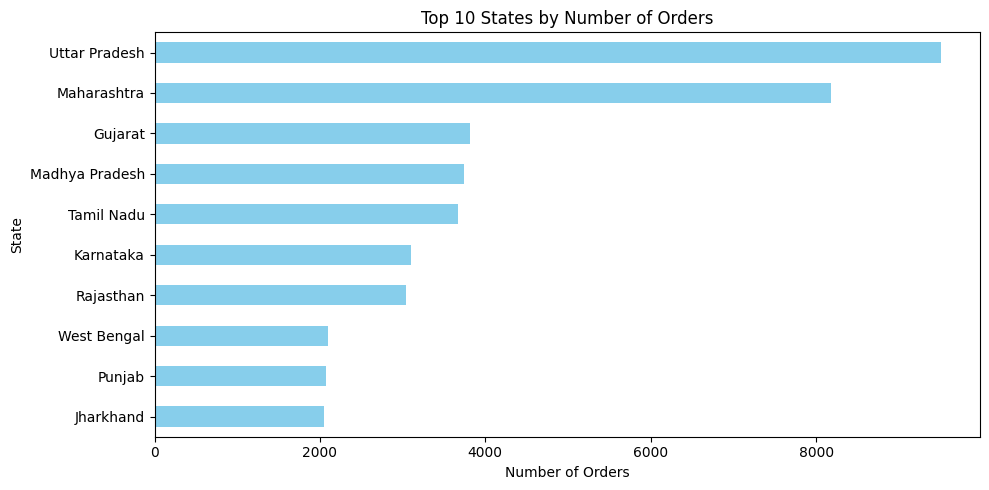

In [18]:
import matplotlib.pyplot as plt

# Merge orders with customers
state_orders = pd.merge(
    orders_df,
    customers_df[['customer_id']],
    on='customer_id',
    how='left'
)

# Count orders by state
state_order_count = (
    state_orders.groupby('state')['order_id']
    .count()
    .sort_values(ascending=False)
)

# Top 10 states
top_10_states = state_order_count.head(10)

print(top_10_states)

# Plot
plt.figure(figsize=(10, 5))
top_10_states.sort_values().plot(kind='barh', color='skyblue')

plt.title('Top 10 States by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('State')

plt.tight_layout()
plt.savefig('top10_states_orders.png')
plt.show()

**Top 10 states by number of orders — In this horizontal bar chart showing top 10 states with orders ,in these states uttar pradesh and maharashtra are top with highest ordered states**

**6.	Customer segment distribution — a pie chart**

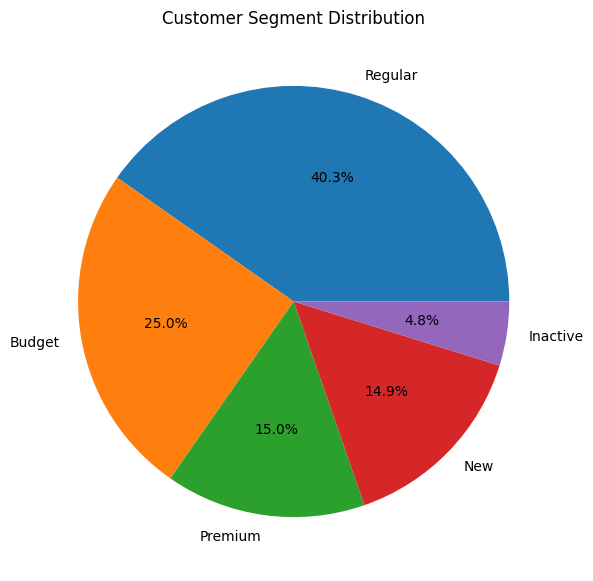

In [19]:
segment = customers_df['segment'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(segment,
        labels=segment.index,
        autopct='%1.1f%%')

plt.title("Customer Segment Distribution")
plt.savefig('chart6_segments.png')
plt.show()

**Customer segment distribution — This pie chart shows How many Premium vs. Regular vs. Budget customers and also this charts presents the regular customers are the highest among all**

**7.	Payment method usage — a bar chart**


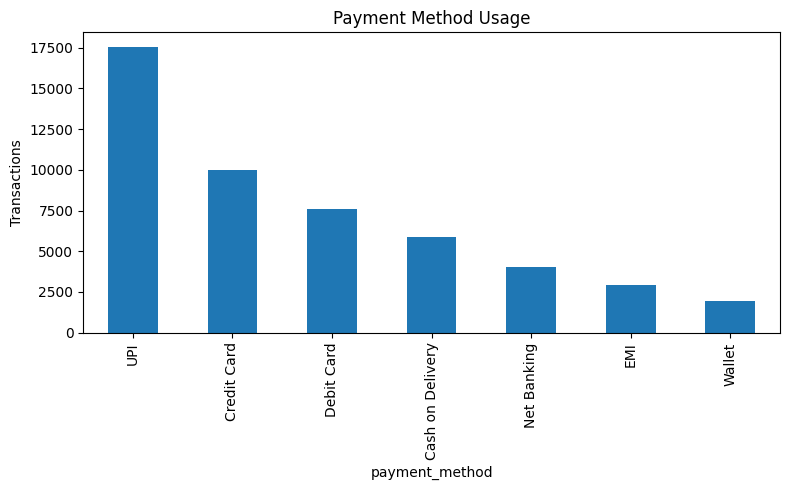

In [20]:
payment = payments_df['payment_method'].value_counts()

plt.figure(figsize=(8,5))
payment.plot(kind='bar')

plt.title("Payment Method Usage")
plt.ylabel("Transactions")

plt.tight_layout()
plt.savefig('chart7_payment_methods.png')
plt.show()

**Payment method usage — a bar chart showing ***UPI*** methods are most popular**

**8.	Age distribution of customers — a histogram**

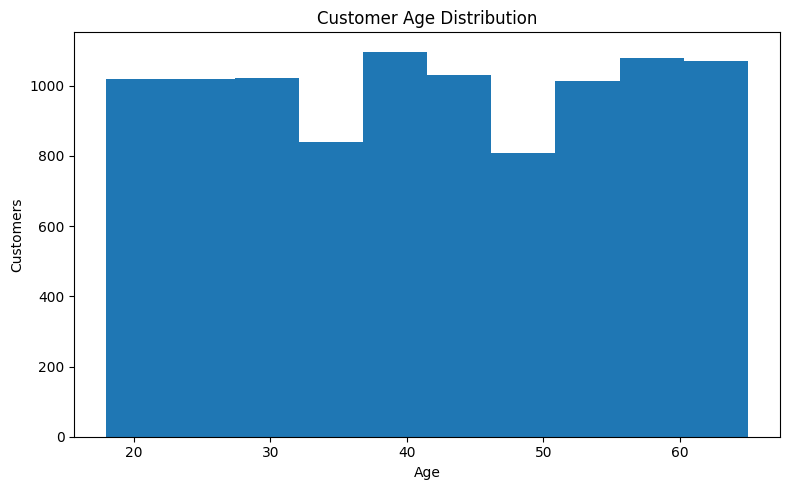

In [21]:
plt.figure(figsize=(8,5))
plt.hist(customers_df['age'], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.tight_layout()
plt.savefig('chart8_age_distribution.png')
plt.show()

**Age distribution of customers — a histogram at 40 and 55 to 65 age group shops most**

**9.	Return reasons — a bar chart**

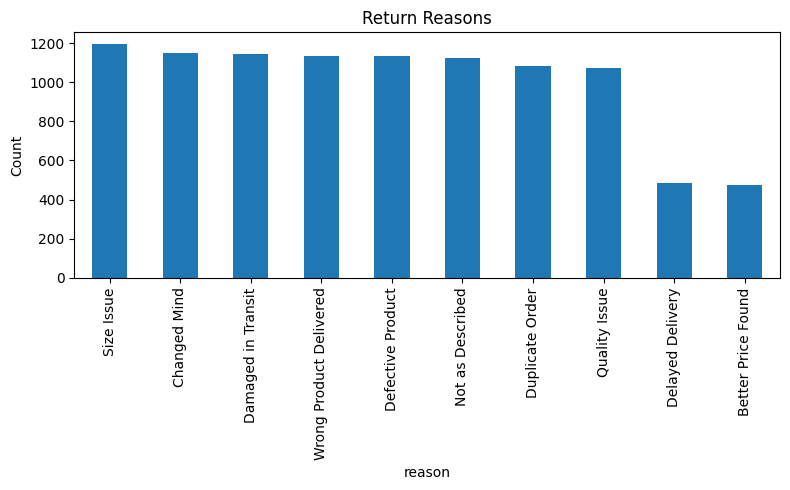

In [22]:
reasons = returns_df['reason'].value_counts()

plt.figure(figsize=(8,5))
reasons.plot(kind='bar')

plt.title("Return Reasons")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig('chart9_return_reasons.png')
plt.show()

**In this bar graph maximum reasons from return csv are size issues and also the changed mind and damaged in transit,wrong product delivered,not as described.**



**10.	Average Order Value (AOV) by segment — a bar chart**

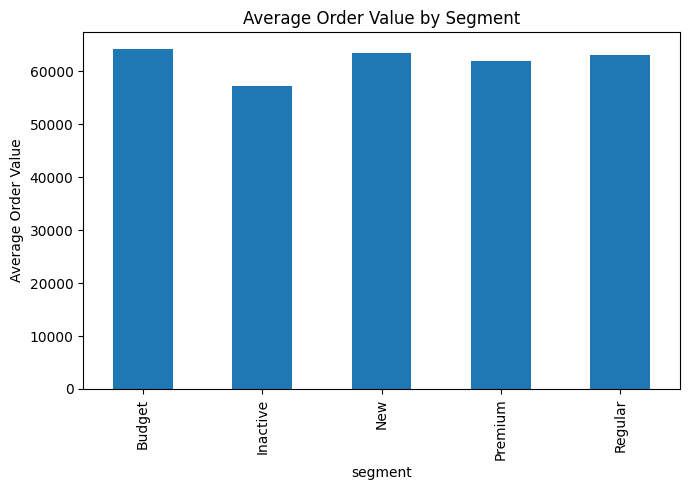

In [23]:
aov = orders_df.merge(
    customers_df[['customer_id','segment']],
    on='customer_id'
)

segment_aov = aov.groupby('segment')['final_amount'].mean()

plt.figure(figsize=(7,5))
segment_aov.plot(kind='bar')

plt.title("Average Order Value by Segment")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.savefig('chart10_aov_segment.png')
plt.show()

**Average Order Value (AOV) by segment — a bar chart, Premium customers spend more per orders and also same as the regular and budgets segments**
